In [1]:
# Hucre 1: Imports ve setup
from google.colab import drive
drive.mount('/content/drive')

import os, sys, cv2, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

# Yollar
PROJECT = Path('/content/drive/MyDrive/DR_Project')
APTOS = PROJECT / 'datasets' / 'aptos2019'
IDRID = PROJECT / 'datasets' / 'IDRiD'
SRC = PROJECT / 'src'
SPLITS = PROJECT / 'splits'
FIG = PROJECT / 'reports' / 'figures'

SRC.mkdir(parents=True, exist_ok=True)
SPLITS.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

# Reproducibility icin seed
SEED = 42
random.seed(SEED); np.random.seed(SEED)

print("OK. Klasorler hazir.")
print(f"  src/    -> {SRC}")
print(f"  splits/ -> {SPLITS}")

Mounted at /content/drive
OK. Klasorler hazir.
  src/    -> /content/drive/MyDrive/DR_Project/src
  splits/ -> /content/drive/MyDrive/DR_Project/splits


In [2]:
%%writefile /content/drive/MyDrive/DR_Project/src/preprocessing.py
"""
Fundus goruntu on-isleme modulu.
Diyabetik Retinopati Analizi - EEM0458 Bahar 2026
Yazar: Can Tekin
"""
import cv2
import numpy as np
from PIL import Image


def crop_fundus(img: np.ndarray, tol: int = 7) -> np.ndarray:
    """
    Fundus goruntusunun siyah arka planini keser, sadece goz dairesini birakir.
    Ben Graham'in (Kaggle 2015 DR yarismasi kazanani) yaklasimi.

    Args:
        img: BGR veya RGB goruntu, np.uint8.
        tol: Siyah piksel esigi. Bu degerden buyuk pikseller "fundus" sayilir.

    Returns:
        Kirpilmis goruntu.
    """
    if img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        gray = img

    mask = gray > tol
    if mask.sum() == 0:
        return img  # tamamen siyah ise dokunma

    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return img[y0:y1, x0:x1]


def apply_clahe(img: np.ndarray, clip_limit: float = 2.0,
                tile_grid_size: tuple = (8, 8)) -> np.ndarray:
    """
    LAB renk uzayinda L kanalina CLAHE uygulayarak kontrasti arttirir.
    Fundus goruntulerinde lezyonlari belirginlestirir.
    """
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_eq = clahe.apply(l)
    lab_eq = cv2.merge([l_eq, a, b])
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)


def resize_square(img: np.ndarray, size: int = 384) -> np.ndarray:
    """
    Goruntuyu kare olacak sekilde sifir-padding ile yeniden boyutlandirir.
    Cember fundus'un en/boy oranini korur.
    """
    h, w = img.shape[:2]
    s = max(h, w)
    pad_top = (s - h) // 2
    pad_bot = s - h - pad_top
    pad_lef = (s - w) // 2
    pad_rig = s - w - pad_lef
    padded = cv2.copyMakeBorder(img, pad_top, pad_bot, pad_lef, pad_rig,
                                cv2.BORDER_CONSTANT, value=[0, 0, 0])
    return cv2.resize(padded, (size, size), interpolation=cv2.INTER_AREA)


def preprocess_pipeline(img_path: str, size: int = 384,
                        apply_clahe_flag: bool = True) -> np.ndarray:
    """
    Tum on-isleme adimlarini sirayla uygular:
    1. Goruntuyu yukle (RGB)
    2. Fundus crop (siyah arka plani kes)
    3. CLAHE (kontrast artirma)
    4. Square padding + resize (size x size)

    Args:
        img_path: Goruntu yolu.
        size: Cikti boyutu.
        apply_clahe_flag: CLAHE uygulansin mi?

    Returns:
        RGB np.uint8 goruntu, sekil (size, size, 3).
    """
    img = np.array(Image.open(img_path).convert('RGB'))
    img = crop_fundus(img, tol=7)
    if apply_clahe_flag:
        img = apply_clahe(img)
    img = resize_square(img, size=size)
    return img


def get_normalization_stats():
    """ImageNet mean/std (transfer learning icin standart)."""
    return {
        'mean': [0.485, 0.456, 0.406],
        'std':  [0.229, 0.224, 0.225],
    }

Writing /content/drive/MyDrive/DR_Project/src/preprocessing.py


In [3]:
# Hucre 3: Preprocessing'i 3 ornek goruntu uzerinde test et
import sys
sys.path.insert(0, str(SRC))
from preprocessing import (crop_fundus, apply_clahe, resize_square,
                           preprocess_pipeline)

# APTOS train.csv yukle
aptos_df = pd.read_csv(APTOS / 'train.csv')

# 3 farkli siniftan birer ornek sec (sinif 0, 2, 4 - dengeli gorsel)
samples = []
for cls in [0, 2, 4]:
    row = aptos_df[aptos_df['diagnosis'] == cls].sample(1, random_state=SEED).iloc[0]
    samples.append((row['id_code'], cls))

class_names = ['No DR', 'Hafif', 'Orta', 'Siddetli', 'Proliferatif']

fig, axes = plt.subplots(3, 4, figsize=(20, 14))

for i, (id_code, cls) in enumerate(samples):
    img_path = APTOS / 'train_images' / f'{id_code}.png'

    # Adim 1: Orijinal
    orig = np.array(Image.open(img_path).convert('RGB'))

    # Adim 2: Crop
    cropped = crop_fundus(orig, tol=7)

    # Adim 3: CLAHE
    clahe_img = apply_clahe(cropped)

    # Adim 4: Final (square + resize 384)
    final = resize_square(clahe_img, size=384)

    stages = [
        (orig, f'1) Orijinal\n{orig.shape[1]}x{orig.shape[0]}'),
        (cropped, f'2) Fundus Crop\n{cropped.shape[1]}x{cropped.shape[0]}'),
        (clahe_img, f'3) CLAHE\n{clahe_img.shape[1]}x{clahe_img.shape[0]}'),
        (final, f'4) Final\n384x384'),
    ]

    for j, (img_arr, title) in enumerate(stages):
        axes[i, j].imshow(img_arr)
        axes[i, j].set_title(title, fontsize=11)
        axes[i, j].axis('off')

    axes[i, 0].set_ylabel(f'{class_names[cls]}\n({id_code})',
                          fontsize=12, fontweight='bold', rotation=0,
                          labelpad=60, va='center')

plt.suptitle('Fundus Goruntu On-Isleme Pipeline\n(Adim 1-4)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()

out_path = FIG / 'fig02_preprocessing_pipeline.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"\nKaydedildi: {out_path}")

# Ozet
print("\n=== Pipeline Ozeti ===")
print(f"Girdi: Degisken boyut (640x480 - 4288x2848 arasi)")
print(f"Cikti: 384x384x3, np.uint8, RGB")
print(f"Adimlar: Crop -> CLAHE -> Square pad -> Resize")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/DR_Project/datasets/aptos2019/train.csv'

In [4]:
import os
print("datasets icerigi:")
for item in sorted(os.listdir(PROJECT / 'datasets')):
    print(" -", repr(item))

# APTOS adayini bul
for item in os.listdir(PROJECT / 'datasets'):
    sub = PROJECT / 'datasets' / item
    if sub.is_dir() and 'aptos' in item.lower():
        print(f"\nAPTOS klasoru: {repr(item)}")
        print("Icerik:")
        for x in sorted(os.listdir(sub)):
            print(" -", repr(x))

datasets icerigi:
 - 'APTOS'
 - 'IDRiD'

APTOS klasoru: 'APTOS'
Icerik:
 - 'test.csv'
 - 'train.csv'
 - 'train_images'


In [5]:
APTOS = PROJECT / 'datasets' / 'APTOS'   # buyuk harfle


In [9]:
# Hucre 1: Imports ve setup
from google.colab import drive
drive.mount('/content/drive')

import os, sys, cv2, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

# Yollar
PROJECT = Path('/content/drive/MyDrive/DR_Project')
APTOS = PROJECT / 'datasets' / 'APTOS'   # buyuk harfle
IDRID = PROJECT / 'datasets' / 'IDRiD'
SRC = PROJECT / 'src'
SPLITS = PROJECT / 'splits'
FIG = PROJECT / 'reports' / 'figures'

SRC.mkdir(parents=True, exist_ok=True)
SPLITS.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

# Reproducibility icin seed
SEED = 42
random.seed(SEED); np.random.seed(SEED)

print("OK. Klasorler hazir.")
print(f"  src/    -> {SRC}")
print(f"  splits/ -> {SPLITS}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OK. Klasorler hazir.
  src/    -> /content/drive/MyDrive/DR_Project/src
  splits/ -> /content/drive/MyDrive/DR_Project/splits


In [10]:
%%writefile /content/drive/MyDrive/DR_Project/src/preprocessing.py
"""
Fundus goruntu on-isleme modulu.
Diyabetik Retinopati Analizi - EEM0458 Bahar 2026
Yazar: Can Tekin
"""
import cv2
import numpy as np
from PIL import Image


def crop_fundus(img: np.ndarray, tol: int = 7) -> np.ndarray:
    """
    Fundus goruntusunun siyah arka planini keser, sadece goz dairesini birakir.
    Ben Graham'in (Kaggle 2015 DR yarismasi kazanani) yaklasimi.

    Args:
        img: BGR veya RGB goruntu, np.uint8.
        tol: Siyah piksel esigi. Bu degerden buyuk pikseller "fundus" sayilir.

    Returns:
        Kirpilmis goruntu.
    """
    if img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        gray = img

    mask = gray > tol
    if mask.sum() == 0:
        return img  # tamamen siyah ise dokunma

    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return img[y0:y1, x0:x1]


def apply_clahe(img: np.ndarray, clip_limit: float = 2.0,
                tile_grid_size: tuple = (8, 8)) -> np.ndarray:
    """
    LAB renk uzayinda L kanalina CLAHE uygulayarak kontrasti arttirir.
    Fundus goruntulerinde lezyonlari belirginlestirir.
    """
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_eq = clahe.apply(l)
    lab_eq = cv2.merge([l_eq, a, b])
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)


def resize_square(img: np.ndarray, size: int = 384) -> np.ndarray:
    """
    Goruntuyu kare olacak sekilde sifir-padding ile yeniden boyutlandirir.
    Cember fundus'un en/boy oranini korur.
    """
    h, w = img.shape[:2]
    s = max(h, w)
    pad_top = (s - h) // 2
    pad_bot = s - h - pad_top
    pad_lef = (s - w) // 2
    pad_rig = s - w - pad_lef
    padded = cv2.copyMakeBorder(img, pad_top, pad_bot, pad_lef, pad_rig,
                                cv2.BORDER_CONSTANT, value=[0, 0, 0])
    return cv2.resize(padded, (size, size), interpolation=cv2.INTER_AREA)


def preprocess_pipeline(img_path: str, size: int = 384,
                        apply_clahe_flag: bool = True) -> np.ndarray:
    """
    Tum on-isleme adimlarini sirayla uygular:
    1. Goruntuyu yukle (RGB)
    2. Fundus crop (siyah arka plani kes)
    3. CLAHE (kontrast artirma)
    4. Square padding + resize (size x size)

    Args:
        img_path: Goruntu yolu.
        size: Cikti boyutu.
        apply_clahe_flag: CLAHE uygulansin mi?

    Returns:
        RGB np.uint8 goruntu, sekil (size, size, 3).
    """
    img = np.array(Image.open(img_path).convert('RGB'))
    img = crop_fundus(img, tol=7)
    if apply_clahe_flag:
        img = apply_clahe(img)
    img = resize_square(img, size=size)
    return img


def get_normalization_stats():
    """ImageNet mean/std (transfer learning icin standart)."""
    return {
        'mean': [0.485, 0.456, 0.406],
        'std':  [0.229, 0.224, 0.225],
    }

Overwriting /content/drive/MyDrive/DR_Project/src/preprocessing.py


In [11]:
# Hucre 3: Preprocessing'i 3 ornek goruntu uzerinde test et
import sys
sys.path.insert(0, str(SRC))
from preprocessing import (crop_fundus, apply_clahe, resize_square,
                           preprocess_pipeline)

# APTOS train.csv yukle
aptos_df = pd.read_csv(APTOS / 'train.csv')

# 3 farkli siniftan birer ornek sec (sinif 0, 2, 4 - dengeli gorsel)
samples = []
for cls in [0, 2, 4]:
    row = aptos_df[aptos_df['diagnosis'] == cls].sample(1, random_state=SEED).iloc[0]
    samples.append((row['id_code'], cls))

class_names = ['No DR', 'Hafif', 'Orta', 'Siddetli', 'Proliferatif']

fig, axes = plt.subplots(3, 4, figsize=(20, 14))

for i, (id_code, cls) in enumerate(samples):
    img_path = APTOS / 'train_images' / f'{id_code}.png'

    # Adim 1: Orijinal
    orig = np.array(Image.open(img_path).convert('RGB'))

    # Adim 2: Crop
    cropped = crop_fundus(orig, tol=7)

    # Adim 3: CLAHE
    clahe_img = apply_clahe(cropped)

    # Adim 4: Final (square + resize 384)
    final = resize_square(clahe_img, size=384)

    stages = [
        (orig, f'1) Orijinal\n{orig.shape[1]}x{orig.shape[0]}'),
        (cropped, f'2) Fundus Crop\n{cropped.shape[1]}x{cropped.shape[0]}'),
        (clahe_img, f'3) CLAHE\n{clahe_img.shape[1]}x{clahe_img.shape[0]}'),
        (final, f'4) Final\n384x384'),
    ]

    for j, (img_arr, title) in enumerate(stages):
        axes[i, j].imshow(img_arr)
        axes[i, j].set_title(title, fontsize=11)
        axes[i, j].axis('off')

    axes[i, 0].set_ylabel(f'{class_names[cls]}\n({id_code})',
                          fontsize=12, fontweight='bold', rotation=0,
                          labelpad=60, va='center')

plt.suptitle('Fundus Goruntu On-Isleme Pipeline\n(Adim 1-4)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()

out_path = FIG / 'fig02_preprocessing_pipeline.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"\nKaydedildi: {out_path}")

# Ozet
print("\n=== Pipeline Ozeti ===")
print(f"Girdi: Degisken boyut (640x480 - 4288x2848 arasi)")
print(f"Cikti: 384x384x3, np.uint8, RGB")
print(f"Adimlar: Crop -> CLAHE -> Square pad -> Resize")

Output hidden; open in https://colab.research.google.com to view.

In [12]:
# Hucre 4: APTOS stratified split + IDRiD external test
from sklearn.model_selection import train_test_split

# APTOS yukle
aptos_df = pd.read_csv(APTOS / 'train.csv')
aptos_df['image_path'] = aptos_df['id_code'].apply(
    lambda x: str(APTOS / 'train_images' / f'{x}.png')
)
aptos_df['dataset'] = 'aptos'
aptos_df = aptos_df.rename(columns={'diagnosis': 'label'})[['image_path', 'label', 'dataset']]

# IDRiD-B yukle (train)
idrid_b_train_csv = (IDRID / 'B. Disease Grading' / '2. Groundtruths' /
                     'a. IDRiD_Disease Grading_Training Labels.csv')
idrid_train = pd.read_csv(idrid_b_train_csv)
idrid_train = idrid_train[['Image name', 'Retinopathy grade']].dropna()
idrid_train['label'] = idrid_train['Retinopathy grade'].astype(int)
idrid_train['image_path'] = idrid_train['Image name'].apply(
    lambda x: str(IDRID / 'B. Disease Grading' / '1. Original Images' /
                  'a. Training Set' / f'{x}.jpg')
)
idrid_train['dataset'] = 'idrid'
idrid_train = idrid_train[['image_path', 'label', 'dataset']]

# IDRiD-B yukle (test) - external test seti olarak ayri tutulacak
idrid_b_test_csv = (IDRID / 'B. Disease Grading' / '2. Groundtruths' /
                    'b. IDRiD_Disease Grading_Testing Labels.csv')
idrid_test = pd.read_csv(idrid_b_test_csv)
idrid_test = idrid_test[['Image name', 'Retinopathy grade']].dropna()
idrid_test['label'] = idrid_test['Retinopathy grade'].astype(int)
idrid_test['image_path'] = idrid_test['Image name'].apply(
    lambda x: str(IDRID / 'B. Disease Grading' / '1. Original Images' /
                  'b. Testing Set' / f'{x}.jpg')
)
idrid_test['dataset'] = 'idrid'
idrid_test = idrid_test[['image_path', 'label', 'dataset']]

print(f"APTOS:        {len(aptos_df)} ornek")
print(f"IDRiD train:  {len(idrid_train)} ornek")
print(f"IDRiD test:   {len(idrid_test)} ornek (external test)")

# APTOS'u stratified split: %80 train, %20 val
aptos_train_df, aptos_val_df = train_test_split(
    aptos_df, test_size=0.20, stratify=aptos_df['label'],
    random_state=SEED
)
print(f"\nAPTOS stratified split:")
print(f"  Train: {len(aptos_train_df)} ({len(aptos_train_df)/len(aptos_df)*100:.1f}%)")
print(f"  Val:   {len(aptos_val_df)} ({len(aptos_val_df)/len(aptos_df)*100:.1f}%)")

# IDRiD train'i APTOS train'e ekle (cross-dataset egitim)
train_df = pd.concat([aptos_train_df, idrid_train], ignore_index=True)
val_df = aptos_val_df.reset_index(drop=True)
test_df = idrid_test.reset_index(drop=True)

# Karistir
train_df = train_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

# Kaydet
train_df.to_csv(SPLITS / 'train.csv', index=False)
val_df.to_csv(SPLITS / 'val.csv', index=False)
test_df.to_csv(SPLITS / 'external_test.csv', index=False)

print(f"\n=== Final Splitler ===")
print(f"TRAIN: {len(train_df)} ornek (APTOS train + IDRiD-B train)")
print(f"VAL:   {len(val_df)} ornek (APTOS val)")
print(f"TEST:  {len(test_df)} ornek (IDRiD-B test, external)")

print(f"\n=== Sinif Dagilimlari ===")
class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'PDR']
dist = pd.DataFrame({
    'Train': train_df['label'].value_counts().sort_index().values,
    'Val':   val_df['label'].value_counts().sort_index().values,
    'Test':  test_df['label'].value_counts().sort_index().values,
}, index=class_names)
dist['Toplam'] = dist.sum(axis=1)
print(dist)
print(f"\nToplam: {dist['Toplam'].sum()} ornek")

print(f"\nCSV'ler kaydedildi:")
print(f"  {SPLITS / 'train.csv'}")
print(f"  {SPLITS / 'val.csv'}")
print(f"  {SPLITS / 'external_test.csv'}")

APTOS:        3662 ornek
IDRiD train:  413 ornek
IDRiD test:   103 ornek (external test)

APTOS stratified split:
  Train: 2929 (80.0%)
  Val:   733 (20.0%)

=== Final Splitler ===
TRAIN: 3342 ornek (APTOS train + IDRiD-B train)
VAL:   733 ornek (APTOS val)
TEST:  103 ornek (IDRiD-B test, external)

=== Sinif Dagilimlari ===
          Train  Val  Test  Toplam
No DR      1578  361    34    1973
Mild        316   74     5     395
Moderate    935  200    32    1167
Severe      228   39    19     286
PDR         285   59    13     357

Toplam: 4178 ornek

CSV'ler kaydedildi:
  /content/drive/MyDrive/DR_Project/splits/train.csv
  /content/drive/MyDrive/DR_Project/splits/val.csv
  /content/drive/MyDrive/DR_Project/splits/external_test.csv


In [13]:
# Albumentations - guclu image augmentation kutuphanesi (segmentasyonda da kullanilacak)
!pip install -q albumentations==1.4.18
import albumentations as A
print("Albumentations:", A.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.0/224.0 kB 7.9 MB/s eta 0:00:00
Albumentations: 1.4.18


/usr/local/lib/python3.12/dist-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [14]:
%%writefile /content/drive/MyDrive/DR_Project/src/dataset.py
"""
DR siniflandirma icin PyTorch Dataset modulu.
Albumentations ile augmentation.
"""
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

sys.path.insert(0, str(Path(__file__).parent))
from preprocessing import preprocess_pipeline, get_normalization_stats

import albumentations as A
from albumentations.pytorch import ToTensorV2


CLASS_NAMES = ['No DR', 'Mild', 'Moderate', 'Severe', 'PDR']


def get_train_transforms(size: int = 384):
    """Egitim icin augmentation pipeline (lezyonu bozmayan agresif)."""
    stats = get_normalization_stats()
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.Rotate(limit=180, border_mode=0, value=0, p=0.7),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=0,
                           border_mode=0, value=0, p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.15,
                                   contrast_limit=0.15, p=0.5),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15,
                             val_shift_limit=10, p=0.4),
        A.GaussianBlur(blur_limit=(3, 5), p=0.2),
        A.Normalize(mean=stats['mean'], std=stats['std']),
        ToTensorV2(),
    ])


def get_val_transforms(size: int = 384):
    """Validation icin sadece normalize (augmentation yok)."""
    stats = get_normalization_stats()
    return A.Compose([
        A.Normalize(mean=stats['mean'], std=stats['std']),
        ToTensorV2(),
    ])


class DRClassificationDataset(Dataset):
    """
    Fundus -> on-isle -> augment -> tensor.
    """
    def __init__(self, csv_path, transform=None, size: int = 384,
                 apply_clahe: bool = True):
        self.df = pd.read_csv(csv_path).reset_index(drop=True)
        self.transform = transform
        self.size = size
        self.apply_clahe = apply_clahe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = preprocess_pipeline(row['image_path'], size=self.size,
                                  apply_clahe_flag=self.apply_clahe)
        if self.transform:
            img = self.transform(image=img)['image']
        label = int(row['label'])
        return img, label


def compute_class_weights(csv_path: str, num_classes: int = 5):
    """
    Sinif dengesizligine karsi class weights hesapla.
    Formul: w_i = N / (K * n_i)   (sklearn'in 'balanced' modu)
    """
    df = pd.read_csv(csv_path)
    counts = df['label'].value_counts().sort_index().values
    N = counts.sum()
    K = num_classes
    weights = N / (K * counts)
    return torch.tensor(weights, dtype=torch.float32)


def get_weighted_sampler(csv_path: str):
    """
    WeightedRandomSampler: her batch'te tum siniflari esit goster.
    Dengesiz veri icin alternatif yontem (class_weight loss yerine).
    """
    df = pd.read_csv(csv_path)
    labels = df['label'].values
    counts = np.bincount(labels)
    sample_weights = 1.0 / counts[labels]
    return WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )

Writing /content/drive/MyDrive/DR_Project/src/dataset.py


Train dataset: 3342 ornek
Val dataset:   733 ornek
Test dataset:  103 ornek

Ornek tensor:
  shape: torch.Size([3, 384, 384])   dtype: torch.float32
  min:   -2.118, max: 2.163
  label: 2 (Moderate)

Class weights (CrossEntropy icin):
  No DR       : 0.424
  Mild        : 2.115
  Moderate    : 0.715
  Severe      : 2.932
  PDR         : 2.345


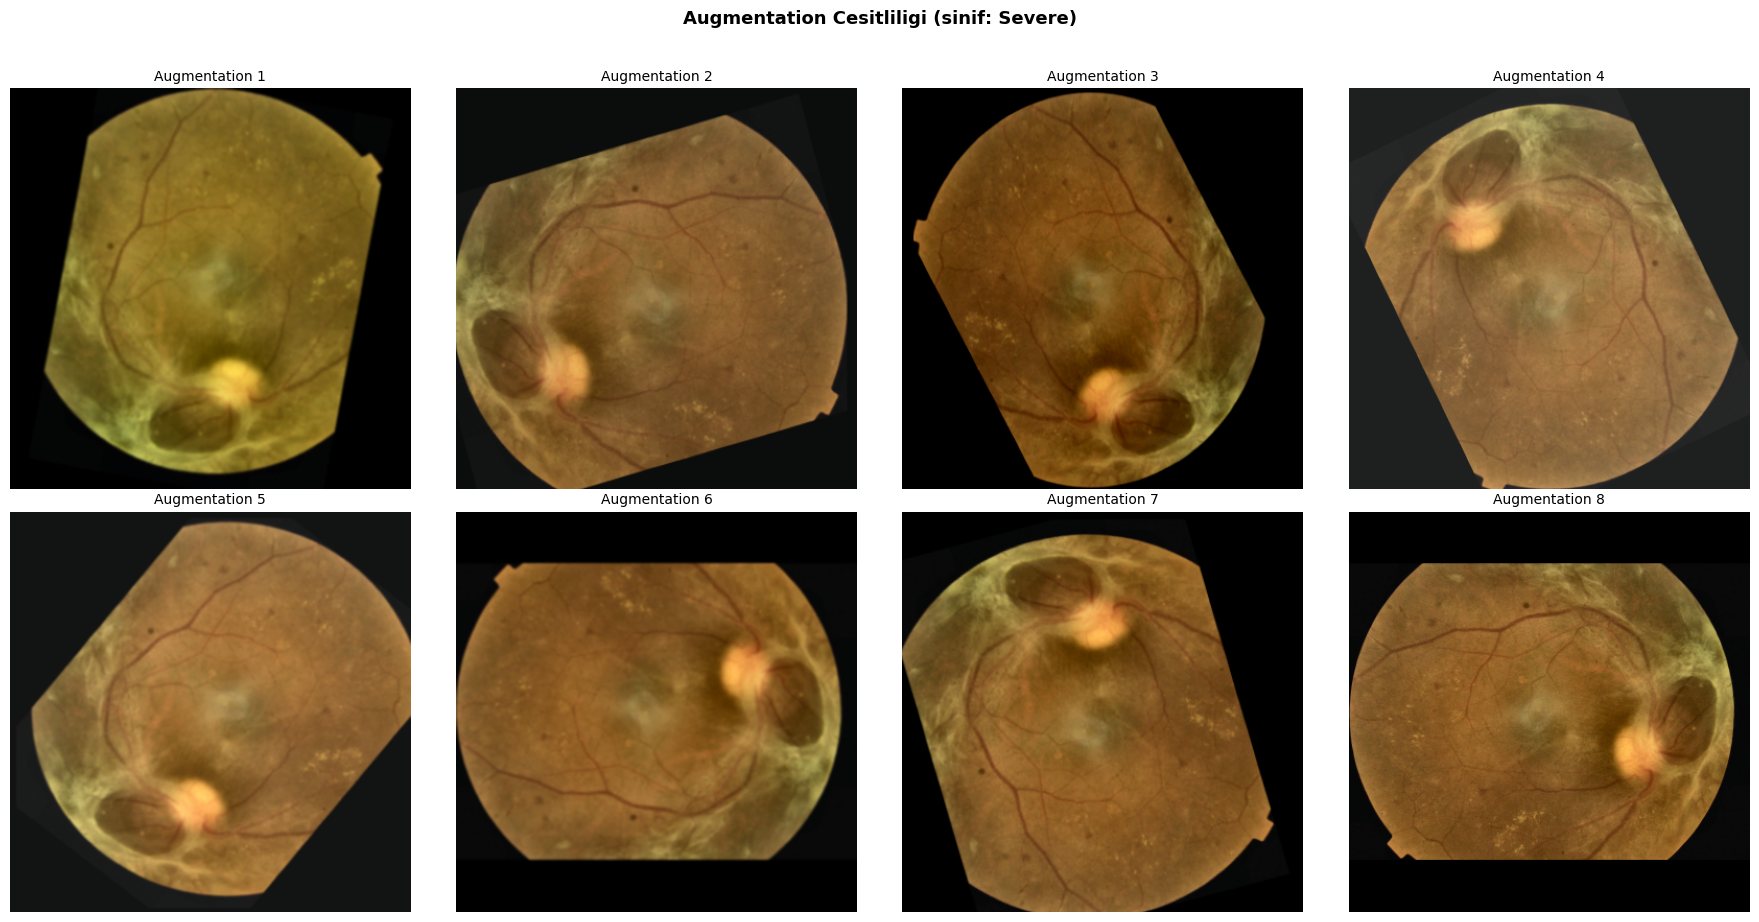


Kaydedildi: /content/drive/MyDrive/DR_Project/reports/figures/fig03_augmentation_examples.png


In [15]:
# Hucre 6: Dataset testi + augmentation gorselleri
import sys
sys.path.insert(0, str(SRC))

# Modullari yeniden yukle (cached eski versiyon olmasin)
import importlib
import preprocessing, dataset
importlib.reload(preprocessing)
importlib.reload(dataset)
from dataset import (DRClassificationDataset, get_train_transforms,
                     get_val_transforms, compute_class_weights, CLASS_NAMES)

# Dataset'leri olustur
train_tf = get_train_transforms(size=384)
val_tf = get_val_transforms(size=384)

train_ds = DRClassificationDataset(SPLITS / 'train.csv', transform=train_tf)
val_ds   = DRClassificationDataset(SPLITS / 'val.csv',   transform=val_tf)
test_ds  = DRClassificationDataset(SPLITS / 'external_test.csv', transform=val_tf)

print(f"Train dataset: {len(train_ds)} ornek")
print(f"Val dataset:   {len(val_ds)} ornek")
print(f"Test dataset:  {len(test_ds)} ornek")

# Tek bir ornegi test et (shape ve dtype dogrulama)
img_t, lbl = train_ds[0]
print(f"\nOrnek tensor:")
print(f"  shape: {img_t.shape}   dtype: {img_t.dtype}")
print(f"  min:   {img_t.min():.3f}, max: {img_t.max():.3f}")
print(f"  label: {lbl} ({CLASS_NAMES[lbl]})")

# Class weights hesapla (egitimde kullanacagiz)
class_weights = compute_class_weights(SPLITS / 'train.csv', num_classes=5)
print(f"\nClass weights (CrossEntropy icin):")
for i, (name, w) in enumerate(zip(CLASS_NAMES, class_weights)):
    print(f"  {name:12s}: {w:.3f}")

# Augmentation gorseli: ayni ornegi 8 farkli augmentation ile goster
import matplotlib.pyplot as plt
stats = preprocessing.get_normalization_stats()
mean = np.array(stats['mean'])
std = np.array(stats['std'])

def denormalize(tensor):
    arr = tensor.permute(1, 2, 0).cpu().numpy()
    arr = arr * std + mean
    return np.clip(arr, 0, 1)

# Severe sinifindan bir ornek bul (lezyonlar belirgin olur)
import pandas as pd
df_train = pd.read_csv(SPLITS / 'train.csv')
severe_idx = df_train[df_train['label'] == 3].index[0]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for i, ax in enumerate(axes.flat):
    img_t, lbl = train_ds[severe_idx]
    ax.imshow(denormalize(img_t))
    ax.set_title(f'Augmentation {i+1}', fontsize=10)
    ax.axis('off')

plt.suptitle(f'Augmentation Cesitliligi (sinif: {CLASS_NAMES[3]})',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
out_path = FIG / 'fig03_augmentation_examples.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"\nKaydedildi: {out_path}")

In [16]:
# Hucre 7: DataLoader hiz testi
import time
import torch
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

BATCH_SIZE = 16
NUM_WORKERS = 2  # Colab T4 icin ideal (CPU 2 core)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

# 10 batch yukle, sure ol
print(f"\n--- 10 batch yuklenme hizi ---")
t0 = time.time()
for i, (imgs, lbls) in enumerate(train_loader):
    imgs = imgs.to(device, non_blocking=True)
    lbls = lbls.to(device, non_blocking=True)
    if i == 0:
        print(f"Ilk batch shape: {imgs.shape}, dtype: {imgs.dtype}, device: {imgs.device}")
    if i >= 9:
        break
elapsed = time.time() - t0
print(f"10 batch yuklendi: {elapsed:.1f}s ({elapsed/10:.2f}s/batch)")
print(f"Tahmini 1 epoch suresi: {elapsed/10 * len(train_loader)/60:.1f} dakika")

# GPU bellek
print(f"\nGPU bellek:")
print(f"  Tahsis: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"  Toplam: {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB")

Device: cuda

--- 10 batch yuklenme hizi ---
Ilk batch shape: torch.Size([16, 3, 384, 384]), dtype: torch.float32, device: cuda:0
10 batch yuklendi: 89.5s (8.95s/batch)
Tahmini 1 epoch suresi: 31.0 dakika

GPU bellek:
  Tahsis: 0.03 GB
  Toplam: 15.64 GB


In [17]:
# Hucre 7.5: Preprocessing cache (lokal SSD'ye - Drive'dan ~30x daha hizli)
import os
import shutil
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image
import sys
sys.path.insert(0, str(SRC))
import importlib, preprocessing
importlib.reload(preprocessing)
from preprocessing import preprocess_pipeline

CACHE_DIR = Path('/content/cache/preprocessed')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

CACHE_SIZE = 384  # Egitim boyutu

def cache_split(csv_path, name):
    df = pd.read_csv(csv_path)
    new_paths = []
    skipped = 0
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f'Cache {name}'):
        src = row['image_path']
        # Unique cache id: dataset adi + dosya adi
        fname = f"{row['dataset']}_{Path(src).stem}.png"
        dst = CACHE_DIR / fname
        if not dst.exists():
            try:
                img = preprocess_pipeline(src, size=CACHE_SIZE,
                                          apply_clahe_flag=True)
                Image.fromarray(img).save(dst, optimize=False)
            except Exception as e:
                skipped += 1
                new_paths.append(None)
                continue
        new_paths.append(str(dst))
    df['image_path'] = new_paths
    df = df.dropna(subset=['image_path']).reset_index(drop=True)

    # Cache'li CSV'yi /content/cache/'e kaydet (Drive'a degil, hizli okuma)
    cache_csv = CACHE_DIR.parent / f'{name}_cached.csv'
    df.to_csv(cache_csv, index=False)
    print(f"  {name}: {len(df)} cache'lendi, {skipped} skip. CSV: {cache_csv}")
    return cache_csv

print("Cache klasoru:", CACHE_DIR)
print()
train_cache = cache_split(SPLITS / 'train.csv', 'train')
val_cache   = cache_split(SPLITS / 'val.csv',   'val')
test_cache  = cache_split(SPLITS / 'external_test.csv', 'test')

# Disk kullanim
total_size = sum(f.stat().st_size for f in CACHE_DIR.glob('*.png')) / 1e6
print(f"\nToplam cache boyutu: {total_size:.0f} MB")
print(f"Dosya sayisi: {len(list(CACHE_DIR.glob('*.png')))}")

Cache klasoru: /content/cache/preprocessed



Cache train:   0%|          | 0/3342 [00:00<?, ?it/s]

  train: 3342 cache'lendi, 0 skip. CSV: /content/cache/train_cached.csv


Cache val:   0%|          | 0/733 [00:00<?, ?it/s]

  val: 733 cache'lendi, 0 skip. CSV: /content/cache/val_cached.csv


Cache test:   0%|          | 0/103 [00:00<?, ?it/s]

  test: 103 cache'lendi, 0 skip. CSV: /content/cache/test_cached.csv

Toplam cache boyutu: 745 MB
Dosya sayisi: 4075


In [18]:
%%writefile /content/drive/MyDrive/DR_Project/src/dataset.py
"""
DR siniflandirma icin PyTorch Dataset modulu.
Cache-aware: onceden islenmis PNG'leri direkt okur.
"""
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image

sys.path.insert(0, str(Path(__file__).parent))
from preprocessing import preprocess_pipeline, get_normalization_stats

import albumentations as A
from albumentations.pytorch import ToTensorV2


CLASS_NAMES = ['No DR', 'Mild', 'Moderate', 'Severe', 'PDR']


def get_train_transforms(size: int = 384):
    stats = get_normalization_stats()
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.Rotate(limit=180, border_mode=0, value=0, p=0.7),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=0,
                           border_mode=0, value=0, p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.15,
                                   contrast_limit=0.15, p=0.5),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15,
                             val_shift_limit=10, p=0.4),
        A.GaussianBlur(blur_limit=(3, 5), p=0.2),
        A.Normalize(mean=stats['mean'], std=stats['std']),
        ToTensorV2(),
    ])


def get_val_transforms(size: int = 384):
    stats = get_normalization_stats()
    return A.Compose([
        A.Normalize(mean=stats['mean'], std=stats['std']),
        ToTensorV2(),
    ])


class DRClassificationDataset(Dataset):
    """
    Cache-aware fundus dataset.
    use_cache=True ise: PNG direkt okunur (cache'li yol bekler).
    use_cache=False ise: tam pipeline (preprocess_pipeline cagrilir).
    """
    def __init__(self, csv_path, transform=None, size: int = 384,
                 use_cache: bool = True, apply_clahe: bool = True):
        self.df = pd.read_csv(csv_path).reset_index(drop=True)
        self.transform = transform
        self.size = size
        self.use_cache = use_cache
        self.apply_clahe = apply_clahe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        if self.use_cache:
            img = np.array(Image.open(row['image_path']).convert('RGB'))
        else:
            img = preprocess_pipeline(row['image_path'], size=self.size,
                                      apply_clahe_flag=self.apply_clahe)
        if self.transform:
            img = self.transform(image=img)['image']
        label = int(row['label'])
        return img, label


def compute_class_weights(csv_path: str, num_classes: int = 5):
    df = pd.read_csv(csv_path)
    counts = df['label'].value_counts().sort_index().values
    N = counts.sum()
    K = num_classes
    weights = N / (K * counts)
    return torch.tensor(weights, dtype=torch.float32)


def get_weighted_sampler(csv_path: str):
    df = pd.read_csv(csv_path)
    labels = df['label'].values
    counts = np.bincount(labels)
    sample_weights = 1.0 / counts[labels]
    return WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )

Overwriting /content/drive/MyDrive/DR_Project/src/dataset.py


In [20]:
# Hucre 9: Cached DataLoader hiz testi
import time
import importlib, dataset
importlib.reload(dataset)
from dataset import DRClassificationDataset, get_train_transforms, get_val_transforms

CACHE = Path('/content/cache')
train_tf = get_train_transforms(384)
val_tf = get_val_transforms(384)

train_ds = DRClassificationDataset(CACHE / 'train_cached.csv', transform=train_tf, use_cache=True)
val_ds   = DRClassificationDataset(CACHE / 'val_cached.csv',   transform=val_tf,   use_cache=True)
test_ds  = DRClassificationDataset(CACHE / 'test_cached.csv',  transform=val_tf,   use_cache=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

BATCH_SIZE = 32  # cache'li okuma hizli, batch buyutebiliriz
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)

t0 = time.time()
for i, (imgs, lbls) in enumerate(train_loader):
    imgs = imgs.to('cuda', non_blocking=True)
    if i == 0:
        print(f"Batch shape: {imgs.shape}")
    if i >= 19:  # 20 batch
        break
elapsed = time.time() - t0
print(f"\n20 batch: {elapsed:.1f}s ({elapsed/20:.2f}s/batch)")
print(f"1 epoch tahmini: {elapsed/20 * len(train_loader)/60:.1f} dakika")


Train: 3342 | Val: 733 | Test: 103
Batch shape: torch.Size([32, 3, 384, 384])

20 batch: 7.4s (0.37s/batch)
1 epoch tahmini: 0.6 dakika
